In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Step 1: Load the Dataset
# The dataset contains information related to kidney disease, with various medical features.
# Ensure the file 'kidney_disease.csv' is in the working directory.
data = pd.read_csv('kidney_disease.csv')

# Step 2: Preview the Dataset Structure
# Use .info() to check the data types, non-null counts, and memory usage.
# This step helps to identify missing values and the types of each column.
print("Dataset Structure:")
print(data.info())  

# Use .head() to view the first few rows for a quick inspection of the data.
# This allows us to understand the general structure and content of the dataset.
print("\nPreview of Dataset (First 5 Rows):")
print(data.head())

Dataset Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              

In [89]:
# Handle missing values
data.fillna(data.mean(numeric_only=True), inplace=True)  # Impute missing values with mean
print(f"\nDataset Shape after handling missing values: {data.shape}")

# Encode categorical columns
categorical_columns = data.select_dtypes(include=['object']).columns
for col in categorical_columns:
    data[col] = LabelEncoder().fit_transform(data[col])



Dataset Shape after handling missing values: (400, 26)


In [77]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Clean column names to remove unexpected characters
data.columns = data.columns.str.strip().str.replace(r'[\t\n\r]', '', regex=True)

# Verify column names containing 'classification'
target_candidates = [col for col in data.columns if 'classification' in col]
print(f"Potential target columns: {target_candidates}")

# Define the target column
target_column = target_candidates[0] if target_candidates else None
if not target_column:
    raise ValueError("No valid target column found in dataset.")

# Encode categorical features
categorical_columns = data.select_dtypes(include=['object']).columns
for col in categorical_columns:
    data[col] = LabelEncoder().fit_transform(data[col])

# Extract features (X) and target (y)
excluded_columns = [col for col in data.columns if 'classification' in col]
X = data.drop(columns=excluded_columns, errors='ignore')  # Features
y = data[target_column]  # Target

# Verify shapes
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Final verification
print(f"Training data: {X_train.shape}, {y_train.shape}")
print(f"Testing data: {X_test.shape}, {y_test.shape}")


Potential target columns: ['classification']
Features shape: (400, 25)
Target shape: (400,)
Training data: (320, 25), (320,)
Testing data: (80, 25), (80,)


In [32]:
import tensorflow as tf

# Define the neural network model using the `Input` layer
model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),  # Specify input shape here
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")

# Save the model
model.save('kidney_disease_model.h5')
print("Model saved as 'kidney_disease_model.h5'")


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.3591 - loss: 0.9164 - val_accuracy: 0.9062 - val_loss: 0.3803
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9959 - loss: 0.2279 - val_accuracy: 1.0000 - val_loss: 0.1373
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9975 - loss: 0.0809 - val_accuracy: 1.0000 - val_loss: 0.0732
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9922 - loss: 0.0539 - val_accuracy: 1.0000 - val_loss: 0.0526
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9953 - loss: 0.0321 - val_accuracy: 1.0000 - val_loss: 0.0414
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9864 - loss: 0.0389 - val_accuracy: 1.0000 - val_loss: 0.0361
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9968 - loss: 0.0157 - val_accuracy: 1.0000 - val_loss: 0.0316
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9950 - loss: 0.0191 - val_accuracy: 1.0000 - val_loss

Test Accuracy: 1.00
Model saved as 'kidney_disease_model.h5'


In [52]:
import tensorflow as tf

# Step 1: Initialize TensorFlow Lite Converter
# Convert the trained Keras model into a TensorFlow Lite format.
# TensorFlow Lite models are optimized for deployment on edge devices such as Raspberry Pi.
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Step 2: Model Conversion
# Convert the Keras model into a lightweight .tflite format suitable for embedded systems.
# The conversion process may include optimizations for size, speed, and compatibility with lower-resource environments.
tflite_model = converter.convert()

# Step 3: Save the Converted Model
# Save the TensorFlow Lite model to a file for deployment or further use.
tflite_model_path = 'kidney_disease_model.tflite'
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

# Step 4: Confirmation Message
# Print a message to confirm the successful conversion and saving of the model.
print(f"Model successfully converted to TensorFlow Lite format and saved as '{tflite_model_path}'")


INFO:tensorflow:Assets written to: C:\Users\nahia\AppData\Local\Temp\tmp1omk7svd\assets


INFO:tensorflow:Assets written to: C:\Users\nahia\AppData\Local\Temp\tmp1omk7svd\assets


Saved artifact at 'C:\Users\nahia\AppData\Local\Temp\tmp1omk7svd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 207), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1902259041296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1902259042832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1902259040528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1902259043024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1902259042448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1902259042064: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model successfully converted to TensorFlow Lite format and saved as 'kidney_disease_model.tflite'


In [56]:
keras_model_path = 'kidney_disease_model.keras'
model.save(keras_model_path)
print(f"Model successfully saved as '{keras_model_path}'")


Model successfully saved as 'kidney_disease_model.keras'


In [58]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [60]:
import tensorflow as tf
import numpy as np

# Step 1: Load the TensorFlow Lite Model
# Load the optimized TensorFlow Lite model for inference.
# TensorFlow Lite models are designed for efficient deployment on embedded devices, such as Raspberry Pi.
interpreter = tf.lite.Interpreter(model_path='kidney_disease_model.tflite')
interpreter.allocate_tensors()

# Step 2: Retrieve Input and Output Details
# Fetch details about the model's input and output layers, including shape and data type, for validation and preprocessing.
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Step 3: Define Test Input Data
# Create a random test input vector with a shape matching the model's expected input.
# This input simulates feature data for prediction and serves as a placeholder for real inputs during testing.
input_data = np.random.rand(1, 207).astype(np.float32)  # Replace `207` with the actual number of features if different.

# Step 4: Perform Inference
# Set the input tensor with the test data and execute the model to perform inference.
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

# Step 5: Retrieve and Display the Output
# Get the prediction results from the model's output tensor.
output_data = interpreter.get_tensor(output_details[0]['index'])
print(f"Predicted Output: {output_data}")


Predicted Output: [[0.4798282]]



Summary Statistics:
                id         age          bp          sg          al          su  \
count  400.000000  400.000000  400.000000  400.000000  400.000000  400.000000   
mean   199.500000   51.483376   76.469072    1.017408    1.016949    0.450142   
std    115.614301   16.974966   13.476298    0.005369    1.272318    1.029487   
min      0.000000    2.000000   50.000000    1.005000    0.000000    0.000000   
25%     99.750000   42.000000   70.000000    1.015000    0.000000    0.000000   
50%    199.500000   54.000000   78.234536    1.017408    1.000000    0.000000   
75%    299.250000   64.000000   80.000000    1.020000    2.000000    0.450142   
max    399.000000   90.000000  180.000000    1.025000    5.000000    5.000000   

              rbc          pc         pcc          ba  ...         pcv  \
count  400.000000  400.000000  400.000000  400.000000  ...  400.000000   
mean     1.262500    0.972500    0.125000    0.075000  ...   29.852500   
std      0.655491    0.593

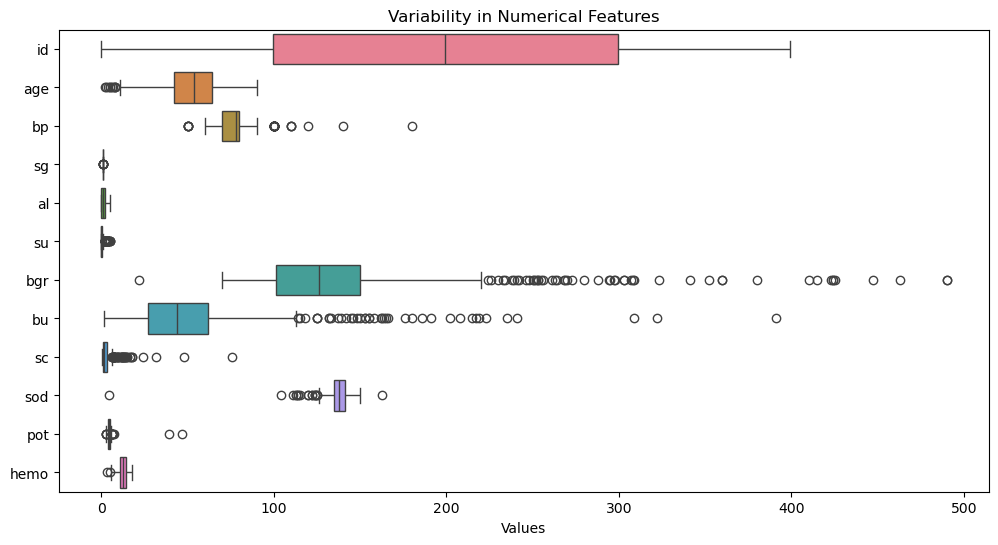

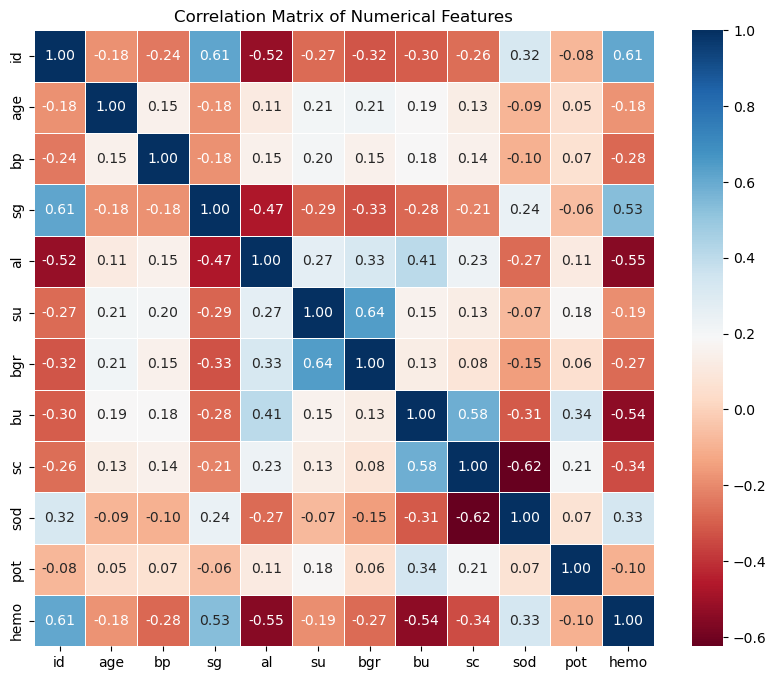

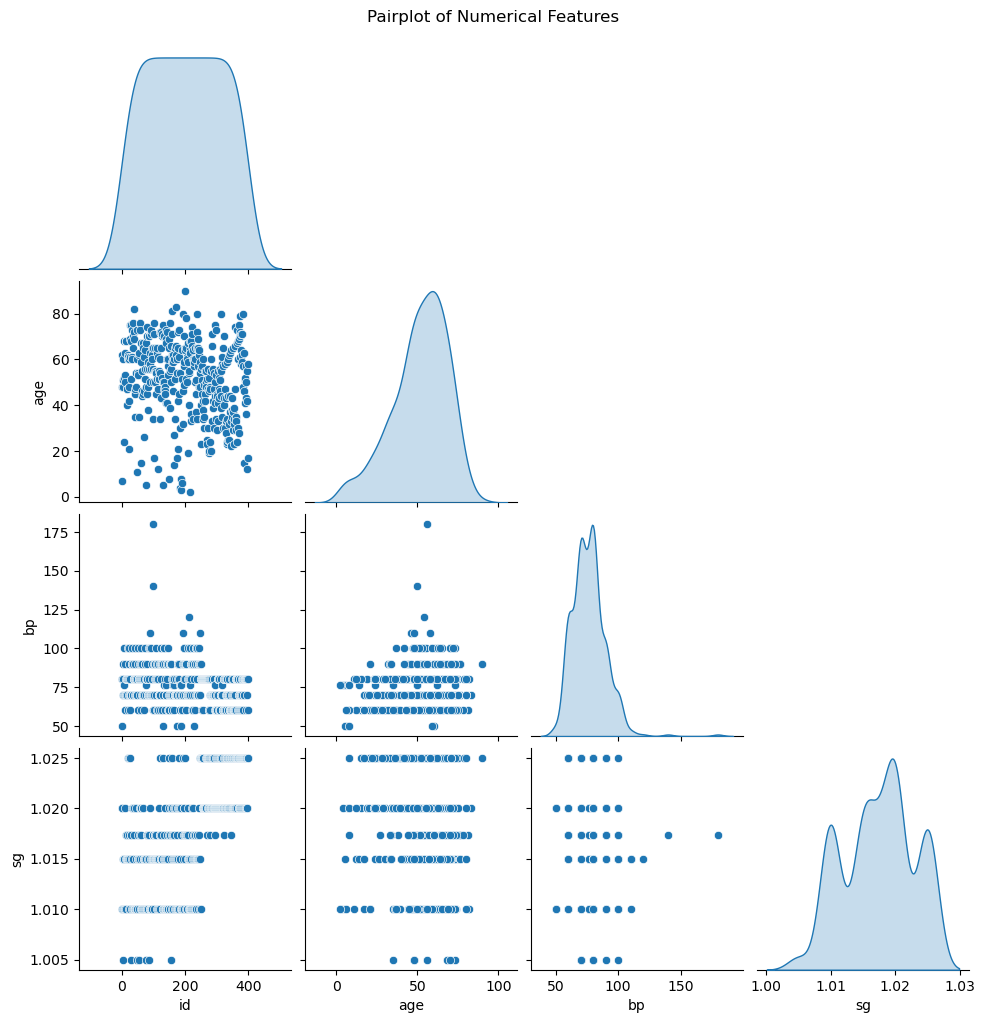

In [91]:
# Descriptive Statistics
print("\nSummary Statistics:\n", data.describe())

# Boxplot for Variability
numerical_features = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
if numerical_features:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=data[numerical_features], orient='h')
    plt.title('Variability in Numerical Features')
    plt.xlabel('Values')
    plt.show()

# Correlation Heatmap
correlation_matrix = data[numerical_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# Pairplot for Select Features
if len(numerical_features) >= 4:
    sns.pairplot(data=data[numerical_features[:4]], diag_kind='kde', corner=True)
    plt.suptitle('Pairplot of Numerical Features', y=1.02)
    plt.show()


In [93]:
# Define target column
target_column = 'classification'  # Replace with your actual target column name
if target_column in data.columns:
    X = data.drop(columns=[target_column])
    y = data[target_column]
else:
    raise ValueError(f"Target column '{target_column}' not found in dataset.")

# Map target labels to {0, 1}
y = y.map({0: 0, 1: 1, 2: 1})  # Modify mapping according to actual target values

# Drop rows where target is NaN after mapping
y.dropna(inplace=True)
X = X.loc[y.index]  # Ensure X matches the filtered y


In [95]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [101]:
# Import the necessary library
from sklearn.linear_model import LogisticRegression

# Model Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [103]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


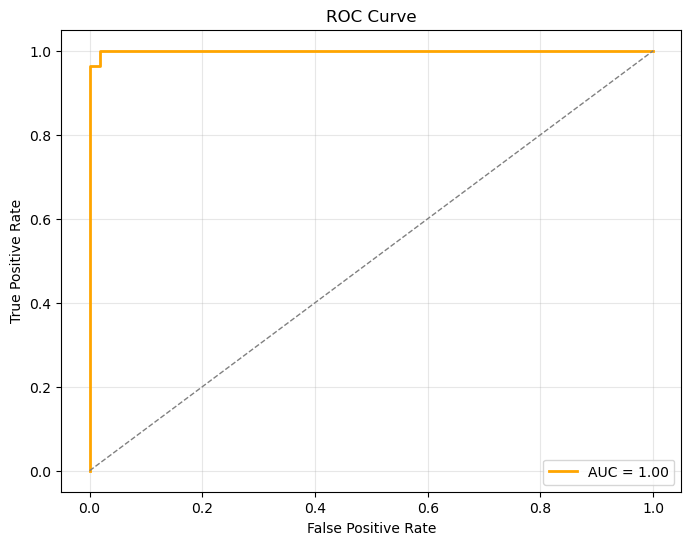

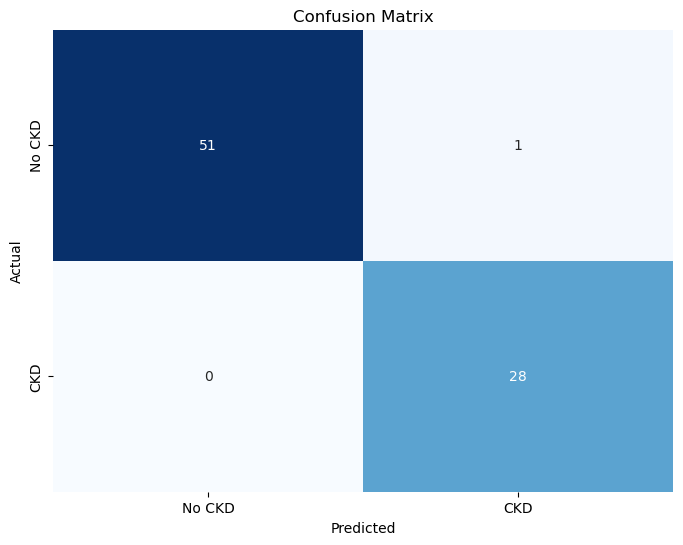

In [107]:
# Import necessary metrics
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', lw=2, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt="d", cbar=False,
            xticklabels=['No CKD', 'CKD'], yticklabels=['No CKD', 'CKD'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


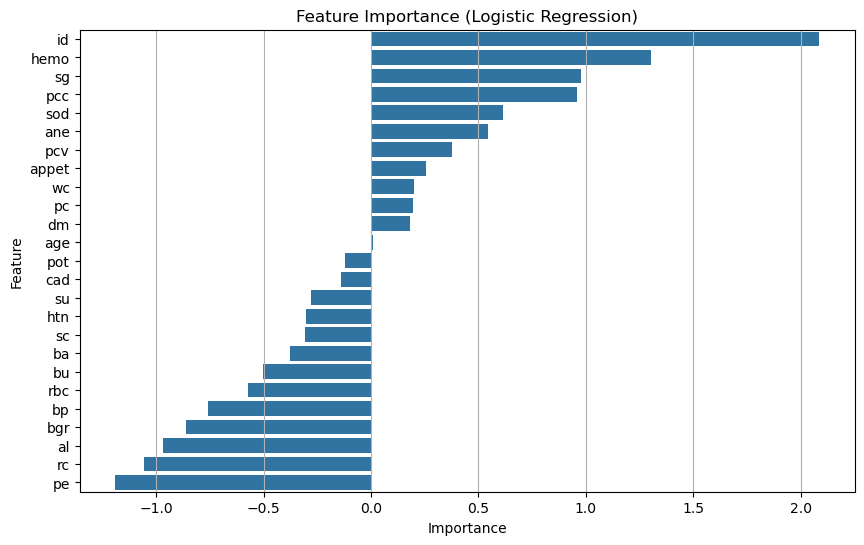

In [109]:
# Feature Importance
if hasattr(model, 'coef_'):
    importance = model.coef_[0]
    feature_importance = pd.DataFrame({
        'Feature': data.drop(columns=[target_column]).columns,
        'Importance': importance
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title('Feature Importance (Logistic Regression)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.grid(axis='x')
    plt.show()
